# Introduction
This project analyzes the United States quarterly GDP growth rates form 2010 to 2023 using data from the U.S.bureau of Economic Analysis (BEA). The values are given as seasonally adjusted annual rate (SAAR) of real GDP growth, in percent. To analyze the data, I will be using three methods: natural cubic spline interpolation, degree 4 polynomial fitting using the normal equations, and least squares linear regression. These methods will allow me to compare interpolation and approximation while evaluating how well each model represents the overall behavior of the data.

In [103]:
import numpy as np
import matplotlib.pyplot as plt

In [104]:
def setup_tridiagonal_matrix(x, y):
    n = len(x)
    
    # Big O: O(n)
    # Reason: one loop through the interior knots
    
    # Step sizes between data points
    h = np.diff(x)
    
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2)  # Subdiagonal
    B = np.zeros(n - 2)  # Main diagonal
    C = np.zeros(n - 2)  # Superdiagonal
    D = np.zeros(n - 2)  # Right-hand side vector
    
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = h[i-1]                                               # Subdiagonal   the below
        B[i - 1] = 2*(h[i-1] + h[i])                                    # Main diagonal
        C[i - 1] = h[i]                                                 # Superdiagonal   the above
        D[i - 1] = 6*( ((y[i+1]-y[i])/h[i]) - ((y[i]-y[i-1])/h[i-1]) )  # Right-hand side vector
                      
    return A, B, C, D

In [105]:
def thomas_algorithm(a1, b1, c1, d1):
    # Big O: O(n)
    # Reason: one forward elimination pass and one back substitution pass
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    x is the second derivative, M
    """
    n = len(b1)
    a = np.copy(a1)
    b = np.copy(b1)
    c = np.copy(c1)
    d = np.copy(d1)
    
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
        
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
        
    return x

In [106]:
def evaluate_spline(x, y, M, x_eval):
    # Big O: O(m log n) in this implementation
    # where m = len(x_eval) and n = len(x)
    # Reason: loop over each evaluation point, and np.searchsorted is logarithmic
    
    # Turn x_eval into an array
    x_eval = np.array(x_eval, dtype=float)
    
    # Store the spline values here
    y_eval = np.zeros_like(x_eval)

    # Go through each x-value we want to evaluate
    for k in range(len(x_eval)):
        current_x = x_eval[k]

        # Find which interval current_x is in
        if current_x == x[-1]:
            i = len(x) - 2
        else:
            i = np.searchsorted(x, current_x) - 1

            # Keep i in a valid range
            if i < 0:
                i = 0
            elif i > len(x) - 2:
                i = len(x) - 2

        # Width of the interval
        h = x[i + 1] - x[i]

        # Terms in the cubic spline formula
        term1 = M[i] * (x[i + 1] - current_x)**3 / (6 * h)
        term2 = M[i + 1] * (current_x - x[i])**3 / (6 * h)
        term3 = (y[i] - M[i] * h**2 / 6) * (x[i + 1] - current_x) / h
        term4 = (y[i + 1] - M[i + 1] * h**2 / 6) * (current_x - x[i]) / h

        # Add the terms to get the spline value
        y_eval[k] = term1 + term2 + term3 + term4

    return y_eval

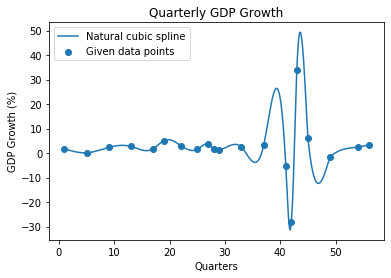

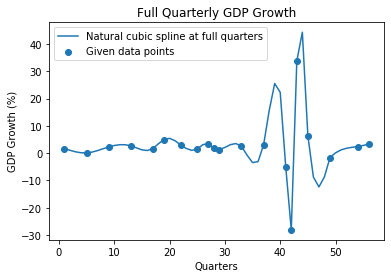

Condition number: 331159708504818.56
Root Mean Squared Error: 10.0314
R-squared: 0.0035


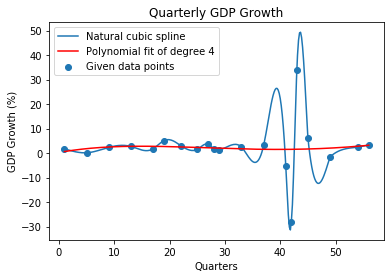

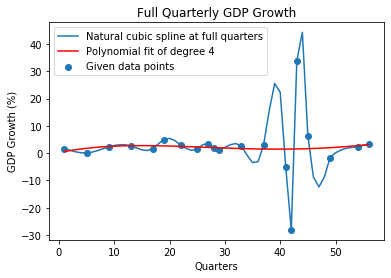

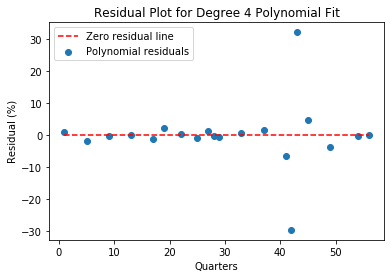

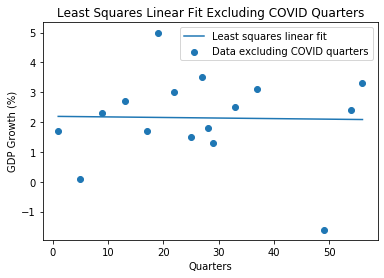

The slope of the Least Square Linear Model: -0.001906988188976378


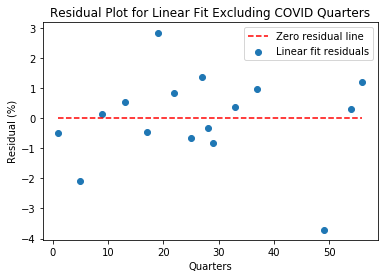

In [111]:
def main():
    # PART A
    
    # Part A.1 Data Set
    x = np.array([1, 5, 9, 13, 17, 19, 22, 25, 27, 28,
                  29, 33, 37, 41, 42, 43, 45, 49, 54, 56])

    y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8,
                  1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])

    # Part A.2 Data Set
    x_full = np.arange(1, 57)
    
    # Set up tridiagonal matrix
    A, B, C, D = setup_tridiagonal_matrix(x, y)
    
    # Solve the matrix using the thomas algortithm
    M_interior = thomas_algorithm(A, B, C, D)
    
    # Second derivatives are computhed with
    # natural spline boundary conditions: M0 = Mn-1 = 0
    n = len(x)
    M = np.zeros(n)
    M[1:n-1] = M_interior

    # New x-points for smooth curve
    x_eval = np.linspace(x[0], x[-1], 300)
    
    # Evaulate the spline at the new points
    y_eval = evaluate_spline(x, y, M, x_eval)
    y_full_eval = evaluate_spline(x, y, M, x_full)

    # Plot A.1 results
    plt.figure()
    plt.scatter(x, y, label="Given data points")
    plt.plot(x_eval, y_eval, label="Natural cubic spline")
    plt.xlabel("Quarters")
    plt.ylabel("GDP Growth (%)")
    plt.title("Quarterly GDP Growth")
    plt.legend()
    plt.show()
    
    # Plot A.2 results
    plt.figure()
    plt.scatter(x, y, label="Given data points")
    plt.plot(x_full, y_full_eval, label="Natural cubic spline at full quarters")
    plt.xlabel("Quarters")
    plt.ylabel("GDP Growth (%)")
    plt.title("Full Quarterly GDP Growth")
    plt.legend()
    plt.show()
    
    #################################################
    # Part B.1
    
    # Create Vandermonde matrix for a polynomial of degree 4
    degree = 4
    # Big O: O(n d), where d = polynomial degree
    V = np.vander(x, N=degree+1, increasing=True)

    # V.T * V
    # Big O: O(n d^2)
    VT_V = np.dot(V.T, V)
    
    # V.T * y
    # Big O: O(n d)
    VT_y = np.dot(V.T, y)
    
    # Solve for a (coefficients)
    # Big O: O(d^3)
    coefficients_vander = np.linalg.solve(VT_V, VT_y)
    
    # Make it smooth
    V_eval = np.vander(x_eval, N=degree+1, increasing=True)
    vander_pred = np.dot(V_eval, coefficients_vander)
    
    # Predictions at original x-values for error metrics
    vander_actual = np.dot(V, coefficients_vander)
    
    #Checking Condition Number
    cond_VT_V = np.linalg.cond(VT_V)
    print("Condition number:", cond_VT_V)
    
    # Root Mean Squared Error (MSE)
    rmse_vander = np.sqrt(np.mean((y - vander_actual)**2))
    print(f'Root Mean Squared Error: {rmse_vander:.4f}')

    # R-squared value
    ss_total_vander = np.sum((y - np.mean(y))**2)
    ss_res_vander = np.sum((y - vander_actual)**2)
    r_squared_vander = 1 - (ss_res_vander / ss_total_vander)
    print(f'R-squared: {r_squared_vander:.4f}')

    # Plot A.1 results against the Vandermonde
    plt.figure()
    plt.scatter(x, y, label="Given data points")
    plt.plot(x_eval, y_eval, label="Natural cubic spline")
    plt.plot(x_eval, vander_pred, color='red', label=f'Polynomial fit of degree {degree}')
    plt.xlabel("Quarters")
    plt.ylabel("GDP Growth (%)")
    plt.title("Quarterly GDP Growth")
    plt.legend()
    plt.show()
    
   # Plot A.2 results against the Vandermonde
    plt.figure()
    plt.scatter(x, y, label="Given data points")
    plt.plot(x_full, y_full_eval, label="Natural cubic spline at full quarters")
    plt.plot(x_eval, vander_pred, color='red', label=f"Polynomial fit of degree {degree}")
    plt.xlabel("Quarters")
    plt.ylabel("GDP Growth (%)")
    plt.title("Full Quarterly GDP Growth")
    plt.legend()
    plt.show()
    
    # Plotting Poly Residuals 
    poly_residuals = y - vander_actual
    
    plt.figure()
    plt.scatter(x, poly_residuals, label="Polynomial residuals")
    plt.plot(x, np.zeros(len(x)), color='red', linestyle='--', label="Zero residual line")
    plt.xlabel("Quarters")
    plt.ylabel("Residual (%)")
    plt.title("Residual Plot for Degree 4 Polynomial Fit")
    plt.legend()
    plt.show()

    # Part B.2
    # Excluding Covid years
    covid_mask = (x < 41) | (x > 48)
    x_no_covid = x[covid_mask]
    y_no_covid = y[covid_mask]
    
     # Creating a least squares linear model
    # Big O: O(n)
    # Reason: sums over the data and elementwise operations are linear in n
    xSum = np.sum(x_no_covid)
    ySum = np.sum(y_no_covid)
    xSquared = x_no_covid * x_no_covid
    xSqSum = np.sum(xSquared)
    xySum = np.sum(x_no_covid* y_no_covid)

    mNumerator = (len(x_no_covid) * xySum) - (xSum * ySum)
    mdenom = (len(x_no_covid) * xSqSum) - (xSum * xSum)
    m = mNumerator / mdenom
    c = (ySum - m * xSum) / len(x_no_covid)

    linear_line = m * x_no_covid + c
    residual = y_no_covid - linear_line
    
        # Plotting least Squares Linear Model
    plt.figure()
    plt.scatter(x_no_covid, y_no_covid, label="Data excluding COVID quarters")
    plt.plot(x_no_covid, linear_line, label="Least squares linear fit")
    plt.title("Least Squares Linear Fit Excluding COVID Quarters")
    plt.xlabel("Quarters")
    plt.ylabel("GDP Growth (%)")
    plt.legend()
    plt.show()
    
    print(f'The slope of the Least Square Linear Model: {m}')

    
    # Plotting Linear Residuals
    linear_residuals = y_no_covid - linear_line
    
    plt.figure()
    plt.scatter(x_no_covid, linear_residuals, label="Linear fit residuals")
    plt.plot(x_no_covid, np.zeros(len(x_no_covid)), color='red', linestyle='--', label="Zero residual line")
    plt.xlabel("Quarters")
    plt.ylabel("Residual (%)")
    plt.title("Residual Plot for Linear Fit Excluding COVID Quarters")
    plt.legend()
    plt.show()
    
    
    
    return 0

if __name__ == "__main__":
    main()


# Part A
1.
For a natural spline, the unknowns are the n−2 interior second derivatives. At each interior knot, the spline satisfies C^0, C^1, and C^2 continuity, which means the function, first derivative, and second derivative all match from both sides. The natural spline boundary conditions is the second derivative is zero at the two endpoints.

2.
The interpolant is not visually smooth because there are multiple sharp turns throughout the line. However, the graph is still reasonable because it passes through each data point.

3.
The Runge phenomenon occurs when interpolating a high degree polynomial or the data set that has outliers which causes large oscillations to occur. Exact interpolation has the line pass through each point, while numerical stability requires you to lose some of the exactness to get a fit that is less sensitive and more reliable. In this case, forcing the spline to pass exactly through the 2020 Q2 value preserves the actual data but can create sharp bending near it, so a smoothing spline or weighted least squares would be preferred for capturing the overall trend, while the natural cubic spline is better if exact interpolation is the goal.


# Part B

1.
The 4th degree polynomial fit better captures the overall trend because it largely ignores the outlier that occured during the covid quarters. However, its very large condition number of 3.31 * 10^14 shows that the fit is ill-conditioned and numerically sensitive. In contrast, The cubic spline better reproduces specific data points becuase it goes through each of them. The trade-off is that the polynomial fitting gives a smoother approximation,but is less accurate. While cubic spline interpolation is more accurate at the known points but more sensitive to extreme values.


2.
The slope of the least squares linear model is about -0.001906. A linear trend does not make sense here as there is no overall trend between the points, which we can tell by looking at the slope which is almost 0, which doesn't show the oscillations between the data points. The assumptions required for a linear trend to make sense is that the data can be accurately modeled by a linear line. Furthermore, that the residuals do not form a curved patteren as that would suggest the linear fit is not appropriate.

# Part C

1.
For a policymaker who needs to estimate GDP growth for a quarter between known data points, I would recommend the cubic spline. Cubic splines are designed for interpolation, are smooth at the knots, and pass through the known data points exactly, so they are more accurate for estimating values between known quarters. Polynomial fitting is a global approximation that focuses more on the overall trend and is more sensitive to outliers, which in this data set are the Covid era data points. In this case, the polynomial fit had an RMSE of about 10 and an R^2 of about 0.0035, which suggests it does not represent the data well, so the cubic spline is the better choice for interpolation.

2.Big O addendum
Big O notation describes how the runtime of an algorithm grows as the input size increases. Building the tridiagonal matrix, solving it with the Thomas algorithm, and computing the linear least squares model are all linear time procedures, O(n). The 4th degree Vandermonde polynomial fit is also effectively O(n) because the degree is fixed. However, evaluating the cubic spline is O(m log n), where m is the number of evaluation points. The tridiagonal matrix setup is O(n)because there is only one loop through the interior knots. The Thomas algorithm is O(n) because it uses one forward elimination pass and one back substitution pass. Evaluating the cubic spline is O(m log n) because it loops over each evaluation point, and np.searchsorted is logarithmic in the number of data points.This does not change my recommendation. Even though evaluating the cubic spline is slightly more time consuming than the other methods, the dataset in this project is small, so the runtime is not a major issue. The cubic spline is still the best choice for interpolation between known data points because it is smooth and passes through the known points.




# Conclusion

To summarise, each method has its pro's and con's. Cubic spline performed best when trying to estimate GDP growth between two data points, but doesn't show the overall trend. Polynomial fitting performed best when trying to determing the overall trend of the data, but not when trying to estimate between two data points. Least squares linear model did not perform well in anything, with oscillations between the data points providing no linear trend made the linear model not very useful for this data set.